<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/6_Competencia_Seleccion_Mejor_Modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# 🏆 **Tercer parcial: Selección del Mejor Modelo**

**ESTÁ PROHIBIDO EL USO DE GRANDES MODELOS DE LENGUAJE COMO CHATGPT, CLAUDE, GEMINI, ENTRE OTROS, PARA RESOLVER ESTE EJERCICIO**

**Trabajo en grupos de 3**

**Objetivo:** Predecir las ventas de una compañía (`Sales`) teniendo en cuenta su inversión en publicidad.

**Dataset:** `train_df_ventas.csv` disponible en el repositorio del curso.

**IMPORTANTE: Los datos cargados solo corresponden a `train`.**

**Metodología:**
1.  Cargar y explorar los datos.
2.  Preprocesar los datos si es necesario.
3.  De los siguientes modelos, entrenar por lo menos 2:
    - Regresión Lineal
    - Regresión Polinómica
    - KNN Regressor
    - Decision Tree Regressor
    - Random Forest Regressor
    - Gradient Boosting Regressor
    - XGBoost Regressor
4.  Si lo considera necesario, usar `GridSearchCV` con Validación Cruzada (`cv=5`) para optimizar los hiperparámetros. La métrica de optimización debe ser el **RMSE** (Root Mean Squared Error), por lo que debe usar `scoring='neg_root_mean_squared_error'` (el valor será negativo y se multiplicará por -1 al final).
5.  Comparar los modelos y seleccionar el mejor, teniendo en cuenta el menor RMSE.

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Tercer_Parcial_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/Bsy2U83tbc. No olvide indicar claramente cuál es el modelo seleccionado.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Calificación**

La docente, evaluará el modelo seleccionado por ustedes en el `test set`.

El proceso seguirá estas reglas:

- **Criterio de Ganador:** El equipo que tenga todo el procedimiento correcto y obtenga el Root Mean Squared Error (RMSE) más bajo en el test set recibirá una calificación de 5.0.

- **Criterio de Desempate:** En caso de empate en el RMSE, se otorgará la ventaja al equipo que haya entrenado y evaluado más modelos.

- **Escalafón de Notas:** A partir del primer puesto, se restará 0.1 a la nota final por cada posición inferior (2º lugar: 4.9, 3er lugar: 4.8, etc.).

- **Validación de Procedimiento:** Es obligatorio que el código sea reproducible por la docente (no olivde colocar las semillas en los procesos aleatorios). Si el script contiene errores, el equipo quedará fuera de la competencia y se dará una calificación acorde a lo que esté correcto.

**Explicación de las variables:**

- Sales: Ventas (millones USD). --> **Esta es la variable objetivo**
- TV: Gasto en promoción televisiva (millones USD).
- Radio: Gasto en promoción radiofónica (millones USD).
- Social Media: Gasto en promoción en redes sociales (millones USD).
- Influencer: Indica si la promoción se realizó en colaboración con Mega, Macro, Nano o Micro influencers.


**Nombres estudiantes del equipo:**

-Juan Pablo Sanchez

-David Ruiz

# **Desarrollo**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.4f}'.format
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42

In [2]:
train_df = pd.read_csv('train_df_ventas.csv')

print("Shape:", train_df.shape)
print("\nTipos de datos:")
print(train_df.dtypes)
print("\nValores nulos:")
print(train_df.isnull().sum())
print("\nCategorías de Influencer:")
print(train_df['Influencer'].value_counts())
display(train_df.head())

Shape: (3636, 5)

Tipos de datos:
TV              float64
Social Media    float64
Influencer       object
Radio           float64
Sales           float64
dtype: object

Valores nulos:
TV              0
Social Media    0
Influencer      0
Radio           0
Sales           0
dtype: int64

Categorías de Influencer:
Influencer
Mega     925
Micro    920
Macro    905
Nano     886
Name: count, dtype: int64


,TV,Social Media,Influencer,Radio,Sales
0,17.5799,1.2190,Macro,22.2822,173.6121
1,14.5885,5.4783,Micro,22.0975,140.5407
2,25.1837,2.2799,Mega,22.1977,197.3528
3,12.8983,1.8315,Nano,21.7413,184.0478
4,28.3805,4.3385,Nano,22.6072,318.6275


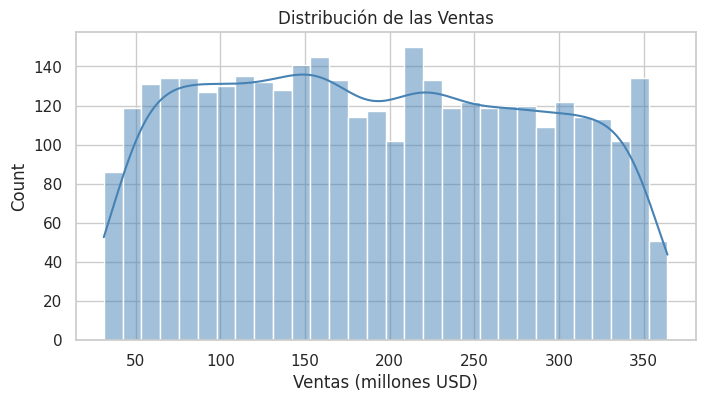

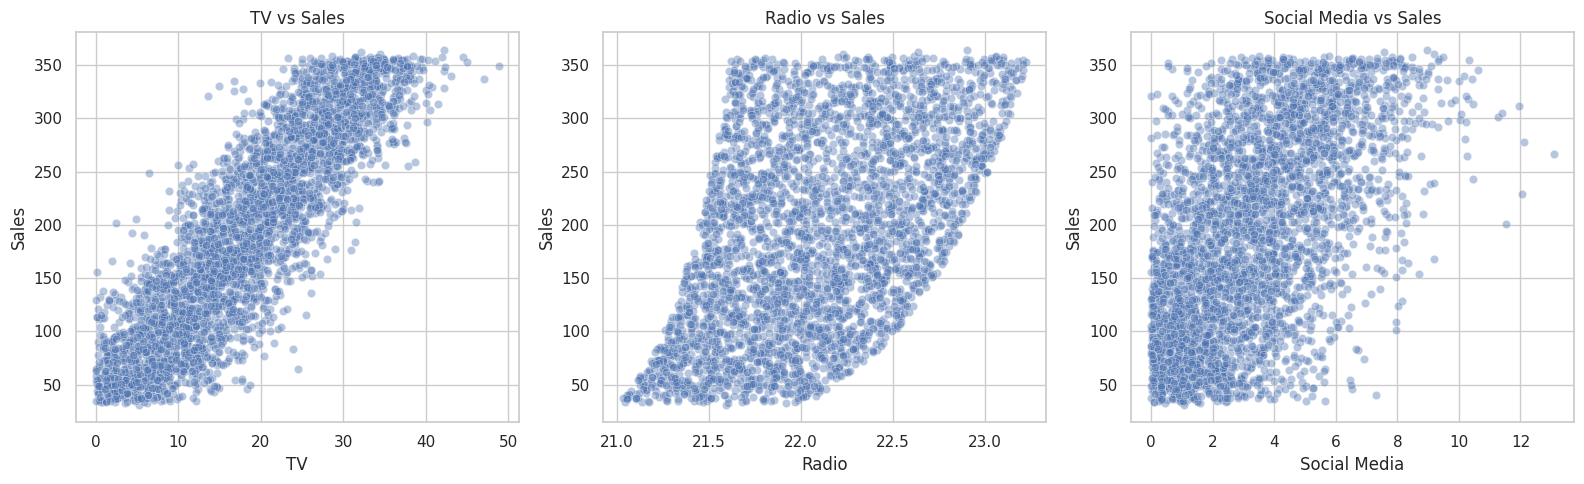

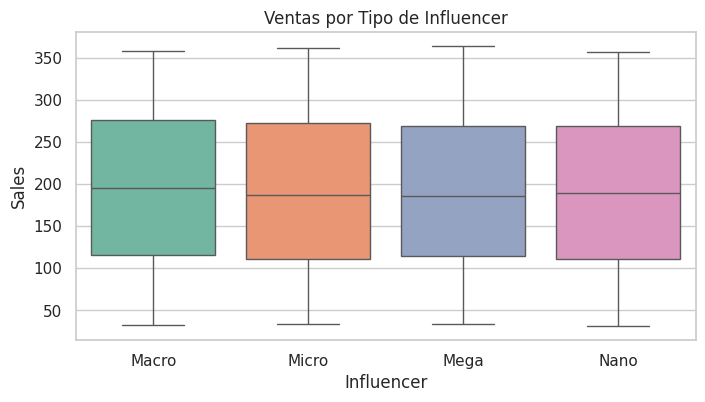

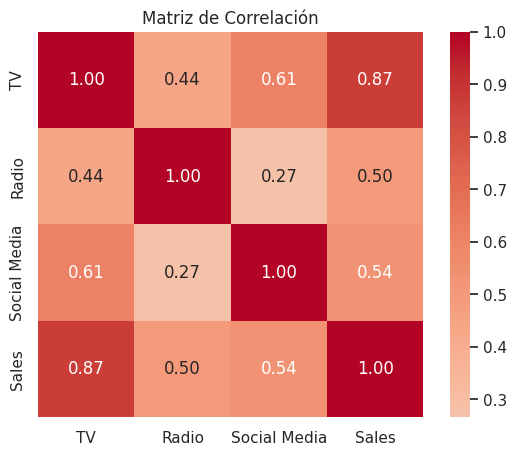

In [3]:
# Distribución de Sales
plt.figure(figsize=(8, 4))
sns.histplot(train_df['Sales'], kde=True, bins=30, color='steelblue')
plt.title('Distribución de las Ventas')
plt.xlabel('Ventas (millones USD)')
plt.show()

# Publicidad vs Sales
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, var in zip(axes, ['TV', 'Radio', 'Social Media']):
    sns.scatterplot(x=train_df[var], y=train_df['Sales'], ax=ax, alpha=0.4)
    ax.set_title(f'{var} vs Sales')
plt.tight_layout()
plt.show()

# Ventas por tipo de Influencer
plt.figure(figsize=(8, 4))
sns.boxplot(x='Influencer', y='Sales', data=train_df, palette='Set2')
plt.title('Ventas por Tipo de Influencer')
plt.show()

# Correlación
plt.figure(figsize=(7, 5))
sns.heatmap(train_df[['TV', 'Radio', 'Social Media', 'Sales']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlación')
plt.show()

In [15]:
X = train_df.drop(columns=['Sales'])
y = train_df['Sales']

num_cols = ['TV', 'Radio', 'Social Media']
cat_cols = ['Influencer']

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)
print("Valores únicos en Influencer:", train_df['Influencer'].unique())

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f"\nTrain: {X_train.shape} | Val: {X_val.shape}")

Variables numéricas: ['TV', 'Radio', 'Social Media']
Variables categóricas: ['Influencer']
Valores únicos en Influencer: ['Macro' 'Micro' 'Mega' 'Nano']

Train: (2908, 4) | Val: (728, 4)


In [16]:
resultados = {}

def evaluar(nombre, grid):
    rmse_cv  = -grid.best_score_
    rmse_val = np.sqrt(mean_squared_error(y_val, grid.predict(X_val)))
    resultados[nombre] = {'RMSE_CV': rmse_cv, 'RMSE_Val': rmse_val,
                          'Mejores_params': grid.best_params_}
    print(f"  Mejor config : {grid.best_params_}")
    print(f"  RMSE CV      : {rmse_cv:.4f}")
    print(f"  RMSE Val     : {rmse_val:.4f}")

In [17]:
print("=== Modelo 1: KNN Regressor ===")

pipe_knn = Pipeline([('pre', preprocessor), ('model', KNeighborsRegressor())])

grid_knn = GridSearchCV(pipe_knn,
    {
        'model__n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 30],
        'model__weights':     ['uniform', 'distance'],
        'model__p':           [1, 2]
    },
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

grid_knn.fit(X_train, y_train)
evaluar('3. KNN', grid_knn)

=== Modelo 1: KNN Regressor ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
  Mejor config : {'model__n_neighbors': 25, 'model__p': 2, 'model__weights': 'distance'}
  RMSE CV      : 44.1103
  RMSE Val     : 44.3714


In [18]:
print("=== Modelo 2: Regresión Polinómica ===")

num_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(include_bias=False))
])

pre_poly = ColumnTransformer(transformers=[
    ('num', num_poly, num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

pipe_poly = Pipeline([('pre', pre_poly), ('model', LinearRegression())])

grid_poly = GridSearchCV(pipe_poly,
    {'pre__num__poly__degree': [2, 3, 4, 5]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)

grid_poly.fit(X_train, y_train)
evaluar('2. Regresion Polinomica', grid_poly)

=== Modelo 2: Regresión Polinómica ===
  Mejor config : {'pre__num__poly__degree': 5}
  RMSE CV      : 41.9088
  RMSE Val     : 41.9582


# **Indica claramente cuál modelo seleccionaste como el mejor**

Nos quedamos con el Modelo de Regresion Polinomica
